# UMAP: Uniform Manifold Approximation and Projection

## Overview

UMAP constructs a weighted graph in high-dimensional space (based on local neighbourhood distances) and finds a low-dimensional representation that preserves this graph structure. It is theoretically grounded in Riemannian geometry and fuzzy set theory.

**UMAP vs. t-SNE:**

| Feature | UMAP | t-SNE |
|---|---|---|
| Speed | Much faster | Slow for n > 10k |
| Global structure | Better preserved | Poor |
| New point embedding | Yes — out-of-sample | No — must rerun |
| Reproducibility | Seed-dependent | Seed-dependent |
| Interpretable axes | No | No |
| Scalability | n > 1M feasible | Impractical > 100k |

**Key parameters:**

| Parameter | Default | Controls |
|---|---|---|
| `n_neighbors` | 15 | Local neighbourhood size; smaller = more local; larger = more global |
| `min_dist` | 0.1 | Minimum distance in 2D; smaller = tighter clusters; larger = spread |
| `n_components` | 2 | Output dimensions |
| `metric` | euclidean | Distance metric in input space |

---

## Setup

In [3]:
library(tidyverse)
library(ggplot2)
library(uwot)          # umap(), umap_transform()
library(patchwork)

set.seed(42)

n_per <- 150
umap_data <- bind_rows(
  tibble(nitrate=rnorm(n_per,2,0.5),  wq=rnorm(n_per,8,0.6),
         phos=rnorm(n_per,0.3,0.08),  turb=rnorm(n_per,3,0.7),
         do2=rnorm(n_per,9.5,0.4),    cond=rnorm(n_per,120,12),
         group="reference"),
  tibble(nitrate=rnorm(n_per,5.5,0.7),wq=rnorm(n_per,5,0.8),
         phos=rnorm(n_per,0.8,0.15),  turb=rnorm(n_per,9,1.2),
         do2=rnorm(n_per,7,0.7),      cond=rnorm(n_per,220,25),
         group="restored"),
  tibble(nitrate=rnorm(n_per,9,0.9),  wq=rnorm(n_per,2.5,0.7),
         phos=rnorm(n_per,1.7,0.22),  turb=rnorm(n_per,18,2),
         do2=rnorm(n_per,4.8,0.9),    cond=rnorm(n_per,360,38),
         group="degraded")
) %>%
  mutate(year=sample(2018:2022, n(), replace=TRUE))

X      <- umap_data %>% select(nitrate:cond) %>% scale()
groups <- umap_data$group
cat(sprintf("%d observations × %d features\n", nrow(X), ncol(X)))

Warning message:
"package 'uwot' was built under R version 4.4.3"


Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Warning message:
"package 'patchwork' was built under R version 4.4.3"


450 observations × 6 features


---

## Fit UMAP

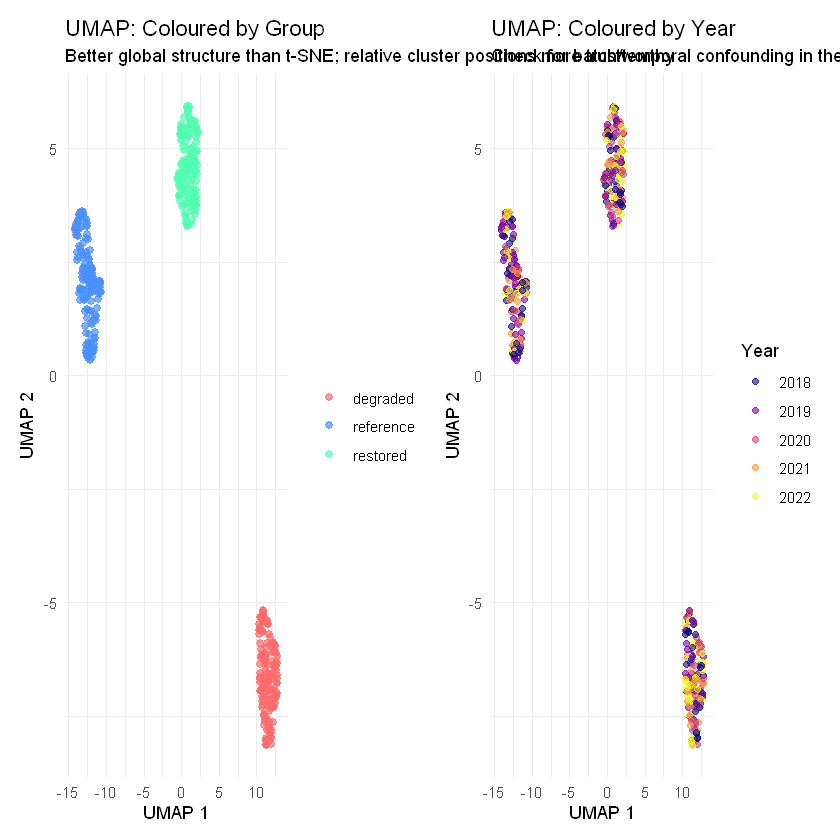

In [4]:
umap_fit <- uwot::umap(
  X,
  n_neighbors  = 15,
  min_dist     = 0.1,
  n_components = 2,
  metric       = "euclidean",
  ret_model    = TRUE,   # save model for out-of-sample embedding
  seed         = 42,
  verbose      = FALSE
)

umap_df <- tibble(
  UMAP1 = umap_fit$embedding[,1],
  UMAP2 = umap_fit$embedding[,2],
  group = groups,
  year  = umap_data$year
)

p_group <- ggplot(umap_df, aes(x=UMAP1, y=UMAP2, color=group)) +
  geom_point(alpha=0.7, size=1.8) +
  scale_color_manual(values=c(reference="#4a8fff",restored="#4fffb0",
                               degraded="#ff6b6b")) +
  labs(title="UMAP: Coloured by Group",
       subtitle="Better global structure than t-SNE; relative cluster positions more trustworthy",
       x="UMAP 1", y="UMAP 2", color=NULL) +
  theme_minimal()

p_year <- ggplot(umap_df, aes(x=UMAP1, y=UMAP2, color=factor(year))) +
  geom_point(alpha=0.6, size=1.5) +
  scale_color_viridis_d(option="plasma", name="Year") +
  labs(title="UMAP: Coloured by Year",
       subtitle="Check for batch/temporal confounding in the embedding",
       x="UMAP 1", y="UMAP 2") +
  theme_minimal()

(p_group | p_year)

---

## Parameter Sensitivity

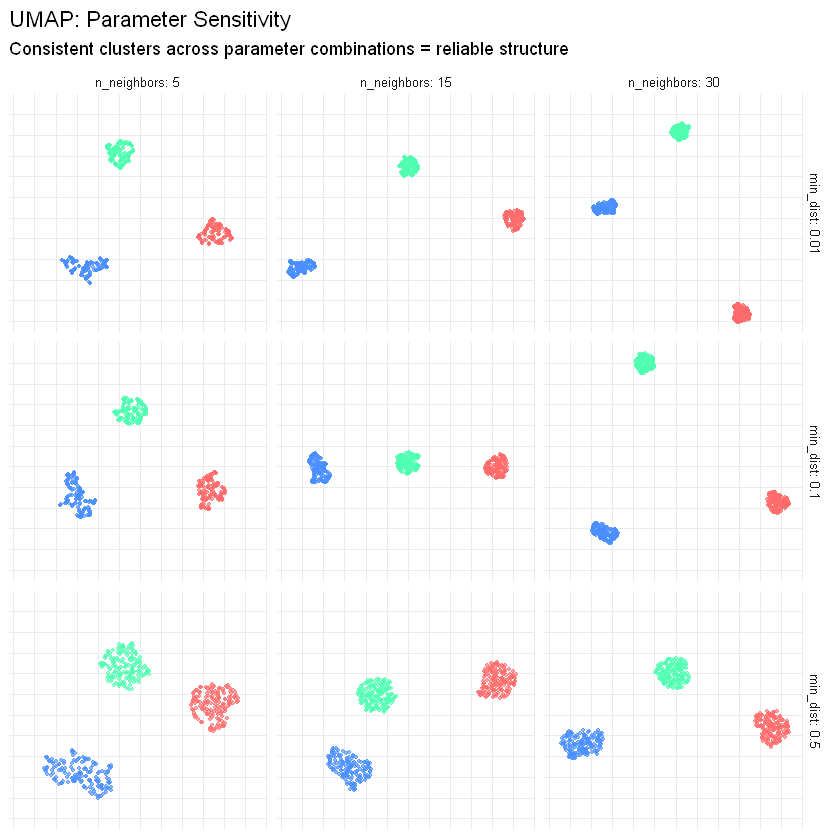

In [5]:
# n_neighbors × min_dist grid
param_grid <- expand_grid(
  n_neighbors = c(5, 15, 30),
  min_dist    = c(0.01, 0.1, 0.5)
)

param_plots <- pmap(param_grid, function(n_neighbors, min_dist) {
  fit <- uwot::umap(X, n_neighbors=n_neighbors, min_dist=min_dist,
                    seed=42, verbose=FALSE)
  tibble(UMAP1=fit[,1], UMAP2=fit[,2], group=groups,
         n_neighbors=n_neighbors, min_dist=min_dist)
}) %>% bind_rows()

ggplot(param_plots, aes(x=UMAP1, y=UMAP2, color=group)) +
  geom_point(size=0.8, alpha=0.6) +
  scale_color_manual(values=c(reference="#4a8fff",restored="#4fffb0",
                               degraded="#ff6b6b"), guide="none") +
  facet_grid(min_dist ~ n_neighbors,
             labeller=label_both) +
  labs(title="UMAP: Parameter Sensitivity",
       subtitle="Consistent clusters across parameter combinations = reliable structure",
       x=NULL, y=NULL) +
  theme_minimal() +
  theme(axis.text=element_blank(), strip.text=element_text(size=8))

---

## Out-of-Sample Embedding (Unique to UMAP)

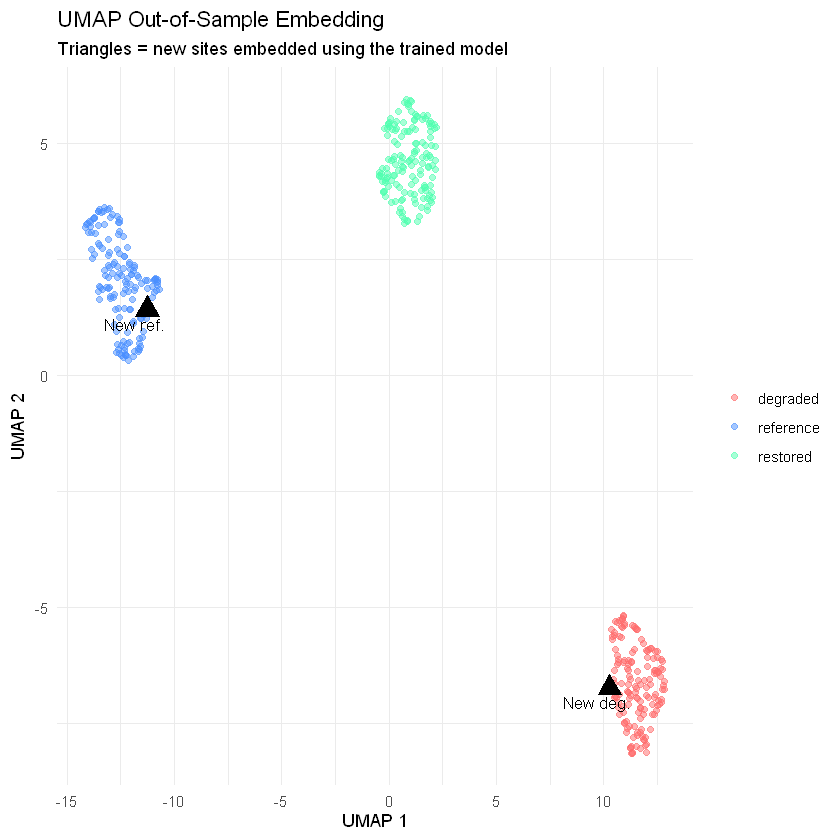

In [7]:
# scale() requires a matrix — wrap each site as a 1-row matrix first
scale_site <- function(x) {
  scale(matrix(x, nrow = 1),
        center = attr(X, "scaled:center"),
        scale  = attr(X, "scaled:scale"))
}

new_sites <- rbind(
  scale_site(c(2.0, 8.5, 0.25, 2.5, 9.8, 115)),   # new reference-like site
  scale_site(c(10.0, 1.8, 2.1, 22.0, 4.2, 390))    # new degraded-like site
)

new_embedded <- uwot::umap_transform(new_sites, umap_fit)

p_oos <- ggplot(umap_df, aes(x = UMAP1, y = UMAP2, color = group)) +
  geom_point(alpha = 0.5, size = 1.5) +
  geom_point(
    data = tibble(UMAP1 = new_embedded[, 1], UMAP2 = new_embedded[, 2],
                  label = c("New ref.", "New deg.")),
    aes(color = NULL), shape = 17, size = 5, color = "black"
  ) +
  ggrepel::geom_text_repel(
    data = tibble(UMAP1 = new_embedded[, 1], UMAP2 = new_embedded[, 2],
                  label = c("New ref.", "New deg.")),
    aes(label = label, color = NULL), size = 3.5, color = "black"
  ) +
  scale_color_manual(values = c(reference = "#4a8fff", restored = "#4fffb0",
                                degraded  = "#ff6b6b")) +
  labs(title    = "UMAP Out-of-Sample Embedding",
       subtitle = "Triangles = new sites embedded using the trained model",
       x = "UMAP 1", y = "UMAP 2", color = NULL) +
  theme_minimal()
p_oos

---

## Common Pitfalls

**1. Concluding from UMAP plots that global distances are meaningful**  
UMAP preserves global structure better than t-SNE, but inter-cluster distances in 2D are still only approximately proportional to distances in the original space. Use UMAP for visualisation and qualitative assessment of groupings — not for quantitative cluster-to-cluster distance analysis.

**2. Not checking parameter sensitivity before reporting**  
UMAP results depend on `n_neighbors` and `min_dist`. Before presenting a UMAP figure, run the 3×3 parameter grid and confirm that the reported structure (number of clusters, group separation) is consistent. Report the parameters used.

**3. Colouring UMAP by a variable correlated with the clustering without noting it**  
If you fit UMAP on features that include a batch variable (year, lab, site), the embedding may reflect that batch structure. Always colour the embedding by potential confounders (batch, technician, collection year) in addition to the scientific groupings of interest.

**4. Using UMAP embeddings as features in a predictive model without proper CV**  
UMAP coordinates are data-dependent and must be computed inside each cross-validation fold on training data only. Using the full-dataset UMAP coordinates as features, then cross-validating a model on them, is a form of preprocessing leakage.

**5. Comparing UMAP embeddings across datasets or time points**  
Two UMAP runs on different datasets — even from the same population — produce incomparable coordinate systems. Axes, orientation, and scale are arbitrary. Use out-of-sample embedding with a fixed trained model (`ret_model=TRUE`, `umap_transform()`) when comparing new observations to an existing reference embedding.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*